In [1]:

# ============================================
# 1. Setup
# ============================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import griddata
import seaborn as sns
from mpl_toolkits.mplot3d import Axes3D
import os 

# --- Aesthetic setup
sns.set_context("notebook", font_scale=1.2)
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (8, 6)


In [2]:
wd = os.getcwd()
wd

'c:\\Users\\andre\\Repositories\\FTZ_model_2.0\\Experiment_Pipeline\\fine_tuning\\results'

In [3]:
# ============================================
# 2. Load Data
# ============================================

file_name = "fine_tune_results_flat.csv"
data_path2 = os.path.join(wd, file_name)



# Load the data into a pandas DataFrame.
df = pd.read_csv(data_path2)

# Print the number of rows loaded to confirm success.
print(f"Loaded {len(df)} rows")

# Display the first few rows of the DataFrame.
print("First 5 rows of the DataFrame:")
df.head()

FileNotFoundError: [Errno 2] No such file or directory: 'c:\\Users\\andre\\Repositories\\FTZ_model_2.0\\Experiment_Pipeline\\fine_tuning\\results\\fine_tune_results_flat.csv'

In [ ]:
def plot_contours(df, cols, n_points=250):
    """
    Visualizes GA parameter response surfaces.
    - Interpolation: 'linear' (robust for irregular GA sampling)
    - Best point: red dot with numeric label
    - Higher metric value = better performance
    """
    import matplotlib.pyplot as plt
    from scipy.interpolate import griddata
    import numpy as np

    x, y = df["mutation_rate"], df["parents_rate"]
    xi = np.linspace(x.min(), x.max(), n_points)
    yi = np.linspace(y.min(), y.max(), n_points)
    xi, yi = np.meshgrid(xi, yi)

    fig, axes = plt.subplots(1, len(cols), figsize=(6 * len(cols), 5))
    if len(cols) == 1:
        axes = [axes]

    for ax, col in zip(axes, cols):
        # Interpolation
        zi = griddata((x, y), df[col], (xi, yi), method="linear")

        # Contour map
        contour = ax.contourf(xi, yi, zi, levels=80, cmap="viridis")
        cbar = plt.colorbar(contour, ax=ax, pad=0.02)
        cbar.set_label(col)

        # Find the best point (max value)
        best_idx = df[col].idxmax()
        best_x = df.loc[best_idx, "mutation_rate"]
        best_y = df.loc[best_idx, "parents_rate"]
        best_val = df.loc[best_idx, col]

        # Scatter all other points
        mask = df.index != best_idx
        ax.scatter(df.loc[mask, "mutation_rate"],
                   df.loc[mask, "parents_rate"],
                   c=df.loc[mask, col],
                   cmap="viridis", edgecolor="k", s=35, alpha=0.7)

        # Highlight best
        ax.scatter(best_x, best_y, color="red", edgecolor="white", s=90, zorder=5)

        # Label the best point
        ax.text(best_x + 0.015, best_y,  # offset a bit to the right
                f"mut={best_x:.3f}\npar={best_y:.3f}\nval={best_val:.2f}",
                color="black", fontsize=9,
                bbox=dict(facecolor="white", alpha=0.7, edgecolor="none"))

        # Axis labels and title
        ax.set_title(f"{col} response surface")
        ax.set_xlabel("Mutation rate")
        ax.set_ylabel("Parents rate")

    plt.suptitle("Contour maps — GA parameter response (higher = better)", fontsize=16, y=1.05)
    plt.tight_layout()
    plt.show()
plot_contours(df, ["max_hard", "max_medium", "max_easy"])



KeyError: 'mutation_rate'

In [ ]:
for col in ["max_hard", "max_medium", "max_easy"]:
    idx = df[col].idxmax()
    print(f"{col} best = {df.loc[idx, col]:.2f} "
          f"at mutation={df.loc[idx, 'mutation_rate']:.3f}, "
          f"parents={df.loc[idx, 'parents_rate']:.3f}")


max_hard best = -3439.27 at mutation=0.015, parents=0.549
max_medium best = -917.01 at mutation=0.015, parents=0.549
max_easy best = -43.92 at mutation=0.079, parents=0.523


In [ ]:
def show_top_combinations(df, cols, top_n=10):
    """
    Displays tables of the top-performing GA parameter combinations
    for each metric in 'cols'.
    Higher metric value = better performance.
    """
    for col in cols:
        print(f"\n=== Top {top_n} combinations for {col} (highest = best) ===")
        display(
            df.sort_values(by=col, ascending=False)
              .head(top_n)[["mutation_rate", "parents_rate", col]]
              .reset_index(drop=True)
              .style.format({
                  "mutation_rate": "{:.3f}",
                  "parents_rate": "{:.3f}",
                  col: "{:.2f}"
              })
              .background_gradient(subset=[col], cmap="viridis")
        )

# Usage
show_top_combinations(df, ["max_hard", "max_medium", "max_easy"])



=== Top 10 combinations for max_hard (highest = best) ===


,mutation_rate,parents_rate,max_hard
0,0.015,0.549,-3439.27
1,0.079,0.523,-3561.02
2,0.106,0.376,-3563.50
3,0.132,0.304,-3570.75
4,0.170,0.236,-3597.61
5,0.121,0.684,-3636.39
6,0.214,0.335,-3646.84
7,0.249,0.174,-3648.98
8,0.255,0.101,-3672.42
9,0.234,0.625,-3678.85



=== Top 10 combinations for max_medium (highest = best) ===


,mutation_rate,parents_rate,max_medium
0,0.015,0.549,-917.01
1,0.079,0.523,-945.46
2,0.106,0.376,-954.39
3,0.132,0.304,-954.93
4,0.170,0.236,-967.45
5,0.121,0.684,-971.18
6,0.292,0.031,-980.65
7,0.249,0.174,-981.90
8,0.255,0.101,-982.53
9,0.214,0.335,-986.77



=== Top 10 combinations for max_easy (highest = best) ===


,mutation_rate,parents_rate,max_easy
0,0.015,0.549,-43.92
1,0.079,0.523,-43.92
2,0.106,0.376,-43.92
3,0.132,0.304,-44.01
4,0.170,0.236,-44.14
5,0.024,0.898,-45.07
6,0.249,0.174,-45.56
7,0.255,0.101,-45.73
8,0.292,0.031,-45.92
9,0.121,0.684,-46.37


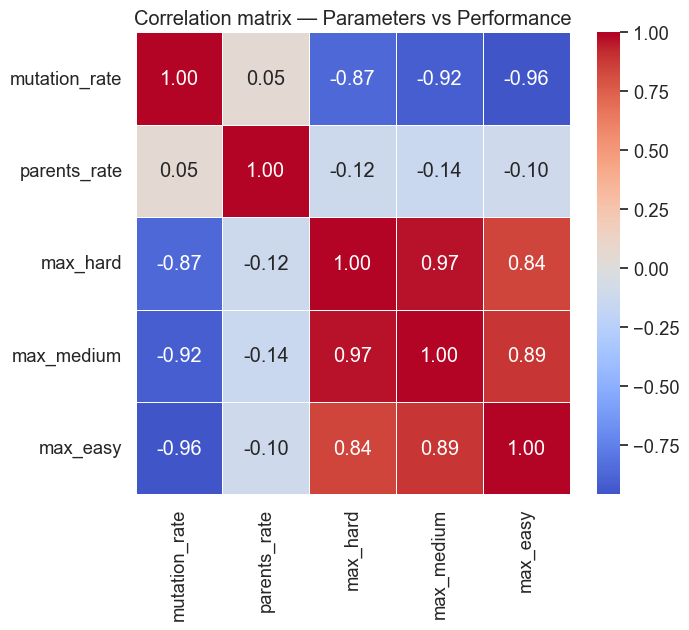

In [ ]:
# ---------------------------------------------------------
# 4. Correlation matrix
# ---------------------------------------------------------
# Shows linear relationships between parameters and metrics
corr = df[["mutation_rate", "parents_rate", "max_hard", "max_medium", "max_easy"]].corr()

plt.figure(figsize=(7, 6))
sns.heatmap(corr, annot=True, cmap="coolwarm", center=0, fmt=".2f", linewidths=0.5)
plt.title("Correlation matrix — Parameters vs Performance")
plt.show()


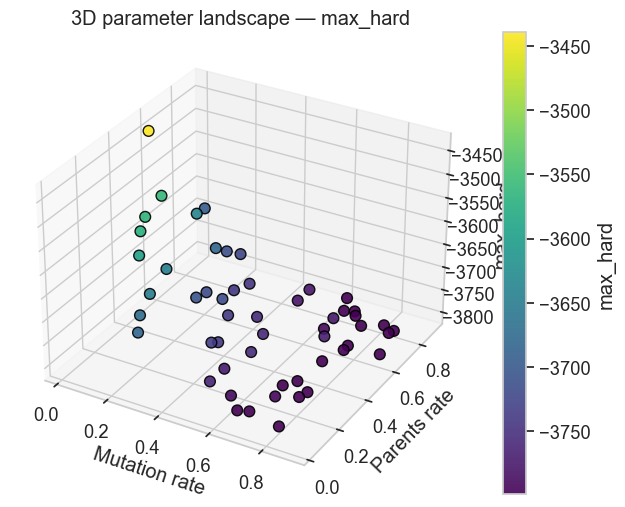

In [ ]:
# ---------------------------------------------------------
# 5. 3D Scatter plot
# ---------------------------------------------------------
# Useful to visualize global trends and nonlinear relationships
def plot_3d(df, metric="max_hard"):
    fig = plt.figure(figsize=(8, 6))
    ax = fig.add_subplot(111, projection="3d")

    sc = ax.scatter(df["mutation_rate"], df["parents_rate"], df[metric],
                    c=df[metric], cmap="viridis", s=60, edgecolor="k", alpha=0.9)
    plt.colorbar(sc, label=metric)

    ax.set_xlabel("Mutation rate")
    ax.set_ylabel("Parents rate")
    ax.set_zlabel(metric)
    ax.set_title(f"3D parameter landscape — {metric}")

    plt.show()

plot_3d(df, "max_hard")